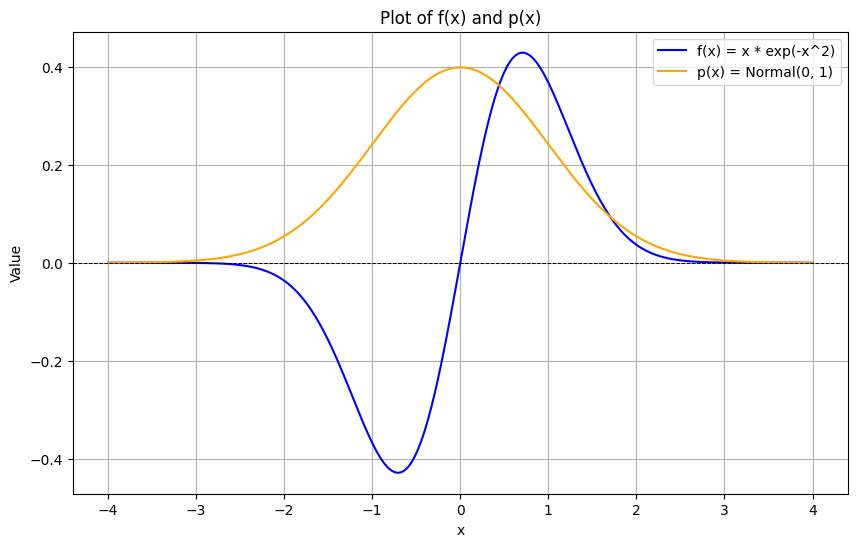

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the x-axis range
x = np.linspace(-4, 4, 500)

# Define f(x): non-periodic, with both positive and negative values
f_x = x * np.exp(-x**2)

# Define p(x): standard normal distribution PDF
p_x = norm.pdf(x, loc=0, scale=1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, f_x, label='f(x) = x * exp(-x^2)', color='blue')
plt.plot(x, p_x, label='p(x) = Normal(0, 1)', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.title('Plot of f(x) and p(x)')
plt.xlabel('x')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

Standard Monte Carlo (from p(x)):
Estimate: 0.135312, Variance: 0.013783

Importance Sampling (from q(x)):
Estimate: 0.123787, Variance: 1.282149


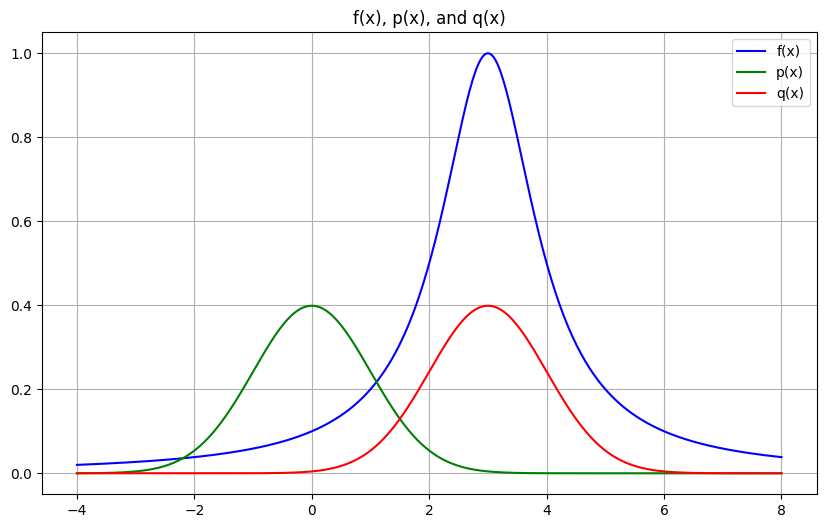

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define f(x) = 1 / (1 + (x - 3)^2) -- peak at x=3
def f(x):
    return 1 / (1 + (x - 3)**2)

# Distributions
p = norm(loc=0, scale=1)   # Standard normal
q = norm(loc=3, scale=1)   # Proposal distribution centered at the peak of f(x)

# Sample size
N = 10000

# Monte Carlo with p(x)
samples_p = p.rvs(size=N)
f_p = f(samples_p)
estimate_p = np.mean(f_p)
var_p = np.var(f_p)

# Importance Sampling with q(x)
samples_q = q.rvs(size=N)
weights = p.pdf(samples_q) / q.pdf(samples_q)
f_q = f(samples_q)
estimate_q = np.mean(f_q * weights)
var_q = np.var(f_q * weights)

# Print results
print("Standard Monte Carlo (from p(x)):")
print(f"Estimate: {estimate_p:.6f}, Variance: {var_p:.6f}")
print("\nImportance Sampling (from q(x)):")
print(f"Estimate: {estimate_q:.6f}, Variance: {var_q:.6f}")

# Plot the functions
x = np.linspace(-4, 8, 500)
plt.figure(figsize=(10, 6))
plt.plot(x, f(x), label='f(x)', color='blue')
plt.plot(x, p.pdf(x), label='p(x)', color='green')
plt.plot(x, q.pdf(x), label='q(x)', color='red')
plt.title('f(x), p(x), and q(x)')
plt.legend()
plt.grid(True)
plt.show()